In [46]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
from thesis.utils import AbsolutePaths
from spectral import *
import matplotlib.pyplot as plt
import rasterio
import cv2
import numpy as np

In [48]:
# Open the .hdr file (which automatically loads the .bsq data)
path_hdr_file = AbsolutePaths().get_abs_path_file('rionegro01_mosaic_geom_atm.hdr')
path_bsq_file = AbsolutePaths().get_abs_path_file('rionegro01_mosaic_geom_atm.bsq')

In [49]:
img = spectral.open_image(path_hdr_file)

In [50]:
img

	Data Source:   'c:\Users\mario\Documents\thesis\data\raw\rionegro01_mosaic_geom_atm.bsq'
	# Rows:           3660
	# Samples:        3438
	# Bands:           379
	Interleave:        BSQ
	Quantization:  16 bits
	Data format:     int16

In [51]:
# Access the wavelegths associated with each band
wavelegths = img.bands.centers

In [52]:
print('Shape of hyperspectral data:', img.shape)
print('Number of bands:', img.shape[2])
print('wavelegths:', wavelegths)

Shape of hyperspectral data: (3660, 3438, 379)
Number of bands: 379
wavelegths: [411.03182, 413.93909, 416.84635, 419.75362, 422.66089, 425.56816, 428.47543, 431.38269, 434.28996, 437.19723, 440.1045, 443.01177, 445.91904, 448.8263, 451.73357, 454.64084, 457.54811, 460.45538, 463.36264, 466.26991, 469.17718, 472.08445, 474.99172, 477.89898, 480.80625, 483.71352, 486.62079, 489.52806, 492.43533, 495.34259, 498.24986, 501.15713, 504.0644, 506.97167, 509.87894, 512.7862, 515.69347, 518.60074, 521.50801, 524.41528, 527.32254, 530.22981, 533.13708, 536.04435, 538.95162, 541.85889, 544.76615, 547.67342, 550.58069, 553.48796, 556.39523, 559.30249, 562.20976, 565.11703, 568.0243, 570.93157, 573.83883, 576.7461, 579.65337, 582.56064, 585.46791, 588.37517, 591.28244, 594.18971, 597.09698, 600.00425, 602.91152, 605.81878, 608.72605, 611.63332, 614.54059, 617.44786, 620.35512, 623.26239, 626.16966, 629.07693, 631.9842, 634.89147, 637.79873, 640.706, 643.61327, 646.52054, 649.42781, 652.33508, 655.

# Direct visualization of the hyperspectral data

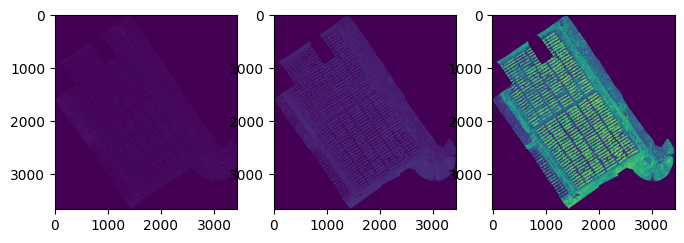

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(8, 25))
ax = ax.flatten()

ind = wavelegths.index(463.36264)
ax[0].imshow(img[:, :, ind])

ind = wavelegths.index(559.30249)
ax[1].imshow(img[:, :, ind])

ind = wavelegths.index(745.36766)
ax[2].imshow(img[:, :, ind])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1e-04..0.3133].


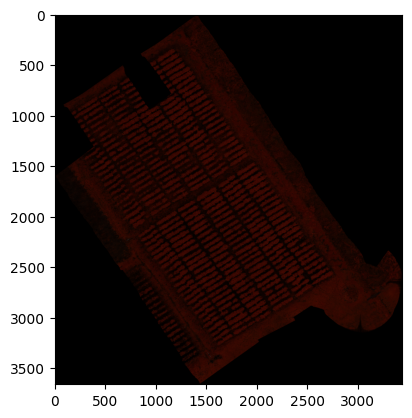

In [54]:
import numpy as np

img2 = np.zeros([3660, 3438, 3], np.float32)

ind1 = wavelegths.index(463.36264)
ind2 = wavelegths.index(559.30249)
ind3 = wavelegths.index(745.36766)

img2[:, :, 2] = np.squeeze(img[:, :, ind1])
img2[:, :, 1] = np.squeeze(img[:, :, ind2])
img2[:, :, 0] = np.squeeze(img[:, :, ind3])

plt.imshow(img2)

# Transform the image to uint8

In [55]:
ind_r = wavelegths.index(460.45538)
ind_g = wavelegths.index(547.67342)
ind_b = wavelegths.index(637.79873)

r, g, b = img[:, :, ind_r], img[:, :, ind_g], img[:, :, ind_b]

print(f"Original data type: {img.dtype}, Min: {np.min(img[:, :, ind_r]):.4f}, Max: {np.max(img[:, :, ind_r]):.4f}")
print(f"Original data type: {img.dtype}, Min: {np.min(img[:, :, ind_g]):.4f}, Max: {np.max(img[:, :, ind_g]):.4f}")
print(f"Original data type: {img.dtype}, Min: {np.min(img[:, :, ind_b]):.4f}, Max: {np.max(img[:, :, ind_b]):.4f}")

Original data type: <i2, Min: -0.0001, Max: 0.2458
Original data type: <i2, Min: -0.0001, Max: 0.2739
Original data type: <i2, Min: -0.0001, Max: 0.2737


In [70]:
def scale_to_uint8(band):
    """Scales a single band to the 0-255 range and converts to uint8."""
    min_val = np.min(band)
    max_val = np.max(band)
    if max_val == min_val:
        scaled_band = np.zeros_like(band, dtype=np.uint8) + 127  # Avoid division by zero
    else:
        normalized_band = (band - min_val) / (max_val - min_val)
        scaled_band = (normalized_band * 255).astype(np.uint8)
    return scaled_band

# def scale_to_float(band):
#     """Escala una banda individual al rango 0-1 (float)."""
#     min_val = np.min(band)
#     max_val = np.max(band)
#     if max_val == min_val:
#         scaled_band = np.zeros_like(band, dtype=np.float32) + 0.5  # Evitar división por cero
#     else:
#         scaled_band = (band - min_val) / (max_val - min_val)
#     return scaled_band

scaled_red = scale_to_uint8(r)
scaled_green = scale_to_uint8(g)
scaled_blue = scale_to_uint8(b)

print(f"Original data type: {scaled_red.dtype}, Min: {np.min(scaled_red):.4f}, Max: {np.max(scaled_red):.4f}")
print(f"Original data type: {scaled_green.dtype}, Min: {np.min(scaled_green):.4f}, Max: {np.max(scaled_green):.4f}")
print(f"Original data type: {scaled_blue.dtype}, Min: {np.min(scaled_blue):.4f}, Max: {np.max(scaled_blue):.4f}")

Original data type: uint8, Min: 0.0000, Max: 255.0000
Original data type: uint8, Min: 0.0000, Max: 255.0000
Original data type: uint8, Min: 0.0000, Max: 255.0000


In [71]:
scaled_red.shape

(3660, 3438, 1)

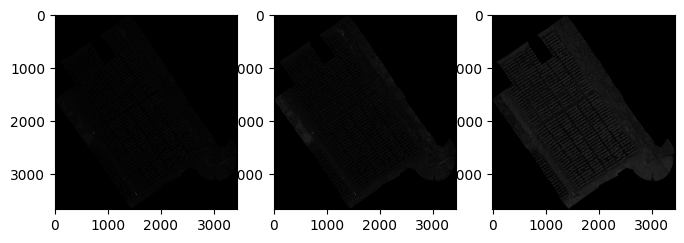

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(8, 10))
ax = ax.flatten()

rgb = cv2.cvtColor(scaled_red, cv2.COLOR_BGR2RGB)
ax[0].imshow(rgb, cmap = plt.cm.Spectral)

rgb = cv2.cvtColor(scaled_blue, cv2.COLOR_BGR2RGB)
ax[1].imshow(rgb, cmap = plt.cm.Spectral)

rgb = cv2.cvtColor(scaled_green, cv2.COLOR_BGR2RGB)
ax[2].imshow(rgb, cmap = plt.cm.Spectral)

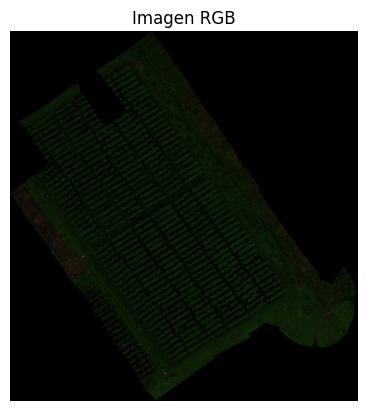

In [74]:
rgb_image = cv2.merge([scaled_blue, scaled_green, scaled_red])
# rgb_image = cv2.merge([scaled_red, scaled_green, scaled_blue])

# Muestra la imagen usando matplotlib
plt.imshow(rgb_image)
plt.title("Imagen RGB")
plt.axis('off')  # Para no mostrar los ejes
plt.show()